# Image denoising

The objective of this exercise is implementing advanced image denoising techniques

## Total variation

In the total variation approach, the denoising process consists of minimizing an energy functional using some optimization technique such as the gradient descent.

1) Given the following functions, implement functions that compute the optimization step using the l2 and total variation equations (see equations 25 and 33 in Lecture 1). Approximate the derivatives by finite differences. 

2) Show how the number of iterations and the parameter lambda affect the results in both methods.

In [1]:
import matplotlib.pyplot as plt
import matplotlib
from skimage.util import random_noise
from skimage import data

import cv2 as cv
import numpy as np
from sklearn.metrics import mean_absolute_error

%matplotlib inline

plt.rcParams['figure.figsize'] = [16,8]


In [2]:
def l2_step(f,u,lmbda):
    
    f = f - u + (lmbda * cv.Laplacian(u, ddepth=-1, ksize=1))
    return f

def tv_step(f,u,lmbda):
        
    ux = cv.filter2D(u, -1, kernel = np.array([[0, 1/2, 0],
                                            [0, 0, 0],
                                            [0, -1/2, 0]]))
    
    uy = cv.filter2D(u, -1, kernel = np.array([[0, 0, 0],
                                            [1/2, 0, -1/2],
                                            [0, 0, 0]]))
    
    uxx = cv.filter2D(u, -1, kernel = np.array([[0, 1, 0],
                                            [0, -2, 0],
                                            [0, 1, 0]]))
    
    uyy = cv.filter2D(u, -1, kernel = np.array([[0, 0, 0],
                                            [1, -2, 1],
                                            [0, 0, 0]]))
    
    uxy = cv.filter2D(ux, -1, kernel = np.array([[0, 0, 0],
                                            [1/2, 0, -1/2],
                                            [0, 0, 0]]))
    
    f = lmbda * (f - u) + (uxx*(uy**2) + uyy*(ux**2) - 2*ux*uy*uxy)/((1e-5 + (ux**2 + uy**2))**(3/2))
    return f

def gradient_descent(f, time_steps, lmbda, delta_t, func):
    
    u_t = f.copy()
    for i in range(time_steps):
        if func == 'l2_step':
            u_t1 = u_t + delta_t * l2_step(f, u_t, lmbda)
        elif func == 'tv_step':
            u_t1 = u_t + delta_t * tv_step(f, u_t, lmbda)   
        
        if mean_absolute_error(u_t1.flatten(), u_t.flatten()) < 1e-5:
            print("Stopping func", func, "in the iteration:", i)
            break
        u_t = u_t1.copy()
         
    return u_t


Stopping func tv_step in the iteration: 61


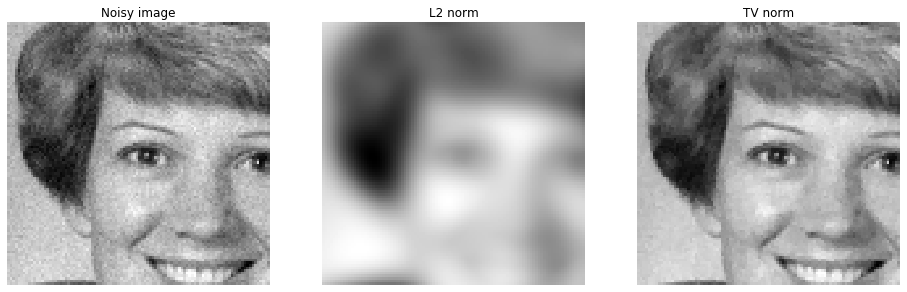

In [3]:
## Iterations = 250 and lmbda = 80
im = data.astronaut()[:,:,1].astype(np.float32)/255
noisy = random_noise(im, var=0.001)

time_steps = 250
lmbda = 80
delta_t = 1e-3
l2_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'l2_step')
tv_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'tv_step')


fig, ax = plt.subplots(1,3)
titles = ['Noisy image', 'L2 norm', 'TV norm']
images = [noisy, l2_result, tv_result]
for i in range(len(ax)):
    ax[i].axis('off')
    ax[i].title.set_text(titles[i])
    ax[i].imshow(images[i][50:150,150:250], cmap='gray')
plt.show()

Stopping func tv_step in the iteration: 60


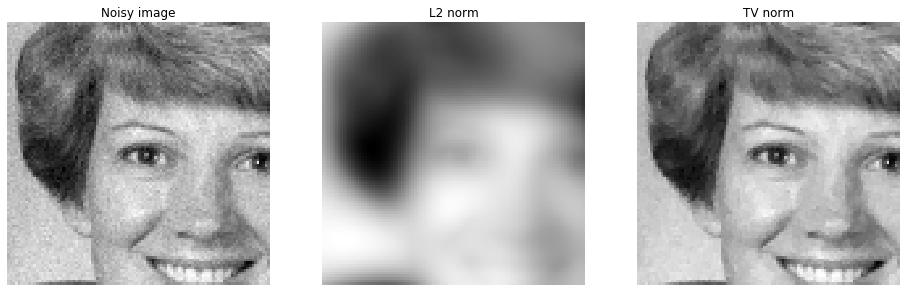

In [4]:
## Iterations = 1000 and lmbda = 80
im = data.astronaut()[:,:,1].astype(np.float32)/255
noisy = random_noise(im, var=0.001)

time_steps = 1000
lmbda = 80
delta_t = 1e-3
l2_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'l2_step')
tv_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'tv_step')


fig, ax = plt.subplots(1,3)
titles = ['Noisy image', 'L2 norm', 'TV norm']
images = [noisy, l2_result, tv_result]
for i in range(len(ax)):
    ax[i].axis('off')
    ax[i].title.set_text(titles[i])
    ax[i].imshow(images[i][50:150,150:250], cmap='gray')
plt.show()

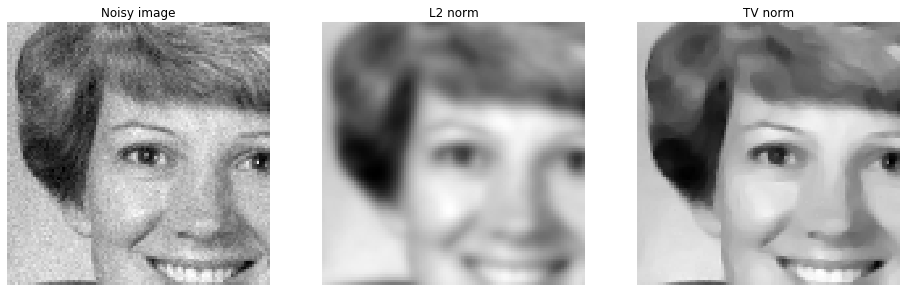

In [5]:
## Iterations = 250 and lmbda = 10
time_steps = 250
lmbda = 10
delta_t = 1e-3
l2_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'l2_step')
tv_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'tv_step')


fig, ax = plt.subplots(1,3)
titles = ['Noisy image', 'L2 norm', 'TV norm']
images = [noisy, l2_result, tv_result]
for i in range(len(ax)):
    ax[i].axis('off')
    ax[i].title.set_text(titles[i])
    ax[i].imshow(images[i][50:150,150:250], cmap='gray')
plt.show()

Stopping func l2_step in the iteration: 929
Stopping func tv_step in the iteration: 284


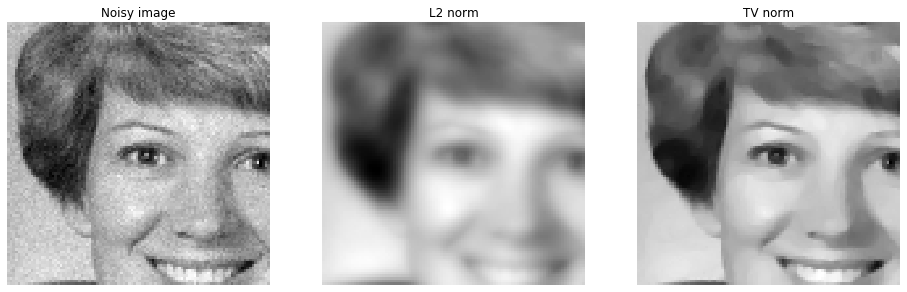

In [6]:
## Iterations = 1000 and lmbda = 10
im = data.astronaut()[:,:,1].astype(np.float32)/255
noisy = random_noise(im, var=0.001)

time_steps = 1000
lmbda = 10
delta_t = 1e-3
l2_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'l2_step')
tv_result = gradient_descent(noisy, time_steps, lmbda, delta_t, 'tv_step')


fig, ax = plt.subplots(1,3)
titles = ['Noisy image', 'L2 norm', 'TV norm']
images = [noisy, l2_result, tv_result]
for i in range(len(ax)):
    ax[i].axis('off')
    ax[i].title.set_text(titles[i])
    ax[i].imshow(images[i][50:150,150:250], cmap='gray')
plt.show()